In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your dataset
# افترضنا أن الملف اسمه reviews.csv والعمود اسمه review والهدف اسمه sentiment
df = pd.read_csv('IMDB Dataset.csv') 
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clean_text(text):
    # Lowercase & remove non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text).lower()
    # Tokenize and remove stopwords
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

# تطبيق التنظيف (قد يستغرق دقيقة حسب حجم البيانات)
df['cleaned_review'] = df['review'].apply(clean_text)
print("Cleaning Done!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kamel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning Done!


In [5]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_review']).toarray()

# تحويل التارجت لأرقام (Positive -> 1, Negative -> 0) لو كان نصوص
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 1. Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 2. Naive Bayes (Bonus)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# التقييم
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nDetailed Report (Logistic Regression):\n", classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8862
Naive Bayes Accuracy: 0.8516

Detailed Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



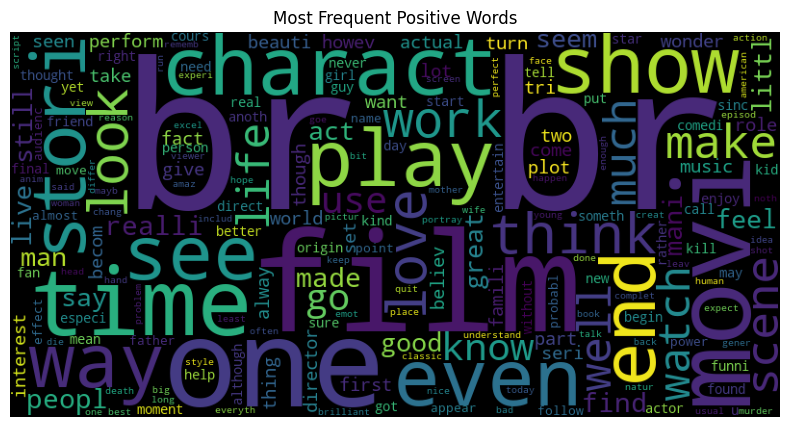

In [8]:
from wordcloud import WordCloud

def plot_cloud(data, title):
    text = " ".join(data)
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.title(title)
    plt.axis('off')
    plt.show()

# عرض الكلمات الإيجابية
plot_cloud(df[df['sentiment'] == 'positive']['cleaned_review'], "Most Frequent Positive Words")